# Model Based Machine learning 42186

## Bayesian Point Process using the SF Police incident data

Every row in the dataset is a single incident with an exact timestamp, a point in time and space. 

This makes it a good structure for a point process problem. 

We model hourly incident counts as Poisson distributed and ask increasingly refined questions:

| Model | Question | Covariates
|---|---|---|
| **M1** | Is the rate constant ? | None | 
| **M2** | Does the rate vary by time of day? | Hour of day, day of week |
| **M3** | Does the rate differ by neighborhood ? | +Analysis neighborhood |
| **M4** | Can neighborhoods share statistical strength? | Hierarchical prior over neighborhoods |

All models are trained with **SVI**. We compare VI to **MCMC (NUTS)** on M1 to validate the approximation.


# 1. Setup

In [88]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pyro
import pyro.distributions as dist
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS, Predictive
from pyro.optim import ClippedAdam

torch.manual_seed(27); pyro.set_rng_seed(27); np.random.seed(27)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

# 2. Data Loading & Preprocessing

We aggregate the processed incident data to hourly counts. Two views:

- **SF-wide**: total per hour - used for M1 and M2.
- **Per-neighborhood**: per hour per analysis neighborhood - used for M3 and M4.


In [89]:
df = pd.read_csv('../../data/processed/incidents_2018_2025.csv', low_memory=False)
df.head()

,Row ID,Incident Datetime,Incident Date,Incident Time,Incident Year,Incident Day of Week,Report Datetime,Incident ID,Incident Number,CAD Number,...,Police District,Analysis Neighborhood,Supervisor District,Supervisor District 2012,Latitude,Longitude,Point,data_as_of,data_loaded_at,hour
0,152278216710,2025-10-31 17:55:00,2025-10-31,17:55,2025,Friday,2025/10/31 05:55:00 PM,1522782,250613625,253042598.0,...,Mission,Mission,9.0,9.0,37.752270,-122.417877,POINT (-122.417877197 37.752269745),2025/11/04 09:37:41 AM,2025/11/05 09:59:28 AM,17
1,148998204134,2025-06-13 12:41:00,2025-06-13,12:41,2025,Friday,2025/06/13 12:46:00 PM,1489982,250329888,251641497.0,...,Ingleside,McLaren Park,9.0,9.0,37.718128,-122.414177,POINT (-122.414176941 37.718128204),2025/06/14 09:37:39 AM,2025/06/15 09:53:25 AM,12
2,152328663010,2025-11-03 14:00:00,2025-11-03,14:00,2025,Monday,2025/11/03 02:00:00 PM,1523286,250269557,NaN,...,Out of SF,NaN,NaN,NaN,NaN,NaN,NaN,2025/11/04 09:37:41 AM,2025/11/05 09:59:28 AM,14
3,149000206224,2025-05-21 00:00:00,2025-05-21,00:00,2025,Wednesday,2025/05/21 08:15:00 AM,1490002,256057940,NaN,...,Ingleside,NaN,NaN,NaN,NaN,NaN,NaN,2025/06/14 09:37:39 AM,2025/06/15 09:53:25 AM,0
4,152326906304,2025-10-23 00:00:00,2025-10-23,00:00,2025,Thursday,2025/11/03 01:24:00 PM,1523269,250618885,253071894.0,...,Richmond,Outer Richmond,1.0,1.0,37.773800,-122.498253,POINT (-122.498252869 37.773799896),2025/11/04 09:37:41 AM,2025/11/05 09:59:28 AM,0


### Summary statistics of the dataset

In [90]:
df.describe()

,Row ID,Incident Year,Incident ID,Incident Number,CAD Number,Incident Code,CNN,Supervisor District,Supervisor District 2012,Latitude,Longitude,hour
count,9.996490e+05,999649.000000,9.996490e+05,9.996490e+05,7.731630e+05,999649.000000,9.441860e+05,943560.000000,944095.000000,944186.000000,944186.000000,999649.000000
mean,1.083803e+11,2021.262123,1.083803e+06,2.142578e+08,2.156602e+08,24114.131096,2.576652e+07,5.984077,6.026340,37.768907,-122.423779,12.888092
std,2.664506e+10,2.261622,2.664506e+05,2.297142e+07,3.214559e+07,25366.854886,4.936153e+06,2.802376,2.788878,0.024408,0.026225,6.488234
min,6.186871e+10,2018.000000,6.186870e+05,0.000000e+00,0.000000e+00,1000.000000,2.001300e+07,1.000000,1.000000,37.707848,-122.511940,0.000000
25%,8.531377e+10,2019.000000,8.531370e+05,1.909088e+08,1.928422e+08,6244.000000,2.394800e+07,3.000000,3.000000,37.753967,-122.434143,9.000000
50%,1.084531e+11,2021.000000,1.084530e+06,2.108193e+08,2.129806e+08,7043.000000,2.492600e+07,6.000000,6.000000,37.775799,-122.417648,14.000000
75%,1.315261e+11,2023.000000,1.315261e+06,2.307579e+08,2.326109e+08,28160.000000,2.647200e+07,9.000000,9.000000,37.785564,-122.407333,18.000000
max,1.562074e+11,2025.000000,1.562073e+06,9.901103e+08,1.000000e+09,75030.000000,5.441200e+07,11.000000,11.000000,37.830055,-122.366287,23.000000


Let us now split the dataset into training and test set:

**Train:** 2018-2023

**Test:** 2024-2025

In [91]:
df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'])
df['hour_bin'] = df['Incident Datetime'].dt.floor('h')
df['hour_of_day'] = df['Incident Datetime'].dt.hour
df['day_of_week'] = df['Incident Datetime'].dt.dayofweek

df_train = df[df['Incident Datetime'].dt.year.isin([2018,2019,2020,2021,2022,2023])].copy()
df_test = df[df['Incident Datetime'].dt.year.isin([2024,2025])].copy()

In [ ]:
def make_hourly_sfwide(subset, t0, t1):
  c = subset.groupby('hour_bin').size().reset_index(name='count')
  idx = pd.date_range(t0, t1, freq='h')[:-1]
  c = c.set_index('hour_bin').reindex(idx, fill_value=0).reset_index()
  c.columns = ['hour_bin', 'count']
  c['hour_of_day'] = c['hour_bin'].dt.hour
  c['day_of_week'] = c['hour_bin'].dt.dayofweek
  return c

def make_hourly_neighborhood(subset, t0, t1, neighborhoods):
    c = subset.groupby(['hour_bin','Analysis Neighborhood']).size().reset_index(name='count')
    idx = pd.MultiIndex.from_product(
        [pd.date_range(t0, t1, freq='h')[:-1], neighborhoods],
        names=['hour_bin','Analysis Neighborhood'])
    c = c.set_index(['hour_bin','Analysis Neighborhood']).reindex(idx, fill_value=0).reset_index()
    c['hour_of_day'] = c['hour_bin'].dt.hour
    c['day_of_week']  = c['hour_bin'].dt.dayofweek
    return c

neighborhoods    = sorted(df['Analysis Neighborhood'].dropna().unique())
neighborhood_map = {n: i for i, n in enumerate(neighborhoods)}
N_NEIGHBORHOODS  = len(neighborhoods)

train_sf   = make_hourly_sfwide(df_train, '2018-01-01', '2024-01-01')
test_sf    = make_hourly_sfwide(df_test,  '2024-01-01', '2026-01-01')
train_dist = make_hourly_neighborhood(df_train, '2018-01-01', '2024-01-01', neighborhoods)
test_dist  = make_hourly_neighborhood(df_test,  '2024-01-01', '2026-01-01', neighborhoods)
train_dist['district_id'] = train_dist['Analysis Neighborhood'].map(neighborhood_map)
test_dist['district_id']  = test_dist['Analysis Neighborhood'].map(neighborhood_map)

print(f"SF-wide       train: {len(train_sf):,}  test: {len(test_sf):,}")
print(f"Neighborhood  train: {len(train_dist):,}  test: {len(test_dist):,}")
print(f"Neighborhoods ({N_NEIGHBORHOODS}): {neighborhoods}")


SF-wide       train: 52,584  test: 17,544
Neighborhood  train: 2,155,944  test: 719,304
Neighborhoods (41): ['Bayview Hunters Point', 'Bernal Heights', 'Castro/Upper Market', 'Chinatown', 'Excelsior', 'Financial District/South Beach', 'Glen Park', 'Golden Gate Park', 'Haight Ashbury', 'Hayes Valley', 'Inner Richmond', 'Inner Sunset', 'Japantown', 'Lakeshore', 'Lincoln Park', 'Lone Mountain/USF', 'Marina', 'McLaren Park', 'Mission', 'Mission Bay', 'Nob Hill', 'Noe Valley', 'North Beach', 'Oceanview/Merced/Ingleside', 'Outer Mission', 'Outer Richmond', 'Pacific Heights', 'Portola', 'Potrero Hill', 'Presidio', 'Presidio Heights', 'Russian Hill', 'Seacliff', 'South of Market', 'Sunset/Parkside', 'Tenderloin', 'Treasure Island', 'Twin Peaks', 'Visitacion Valley', 'West of Twin Peaks', 'Western Addition']


Create tensors

In [ ]:
counts_tr_sf = torch.tensor(train_sf['count'].values,       dtype=torch.float32)
hour_tr_sf   = torch.tensor(train_sf['hour_of_day'].values, dtype=torch.long)
dow_tr_sf    = torch.tensor(train_sf['day_of_week'].values, dtype=torch.long)

counts_te_sf = torch.tensor(test_sf['count'].values,        dtype=torch.float32)
hour_te_sf   = torch.tensor(test_sf['hour_of_day'].values,  dtype=torch.long)
dow_te_sf    = torch.tensor(test_sf['day_of_week'].values,  dtype=torch.long)

counts_tr_d  = torch.tensor(train_dist['count'].values,         dtype=torch.float32)
hour_tr_d    = torch.tensor(train_dist['hour_of_day'].values,   dtype=torch.long)
dow_tr_d     = torch.tensor(train_dist['day_of_week'].values,   dtype=torch.long)
distid_tr_d  = torch.tensor(train_dist['district_id'].values,   dtype=torch.long)

counts_te_d  = torch.tensor(test_dist['count'].values,          dtype=torch.float32)
hour_te_d    = torch.tensor(test_dist['hour_of_day'].values,    dtype=torch.long)
dow_te_d     = torch.tensor(test_dist['day_of_week'].values,    dtype=torch.long)
distid_te_d  = torch.tensor(test_dist['district_id'].values,    dtype=torch.long)

print(f"Mean hourly count (SF-wide):           {counts_tr_sf.mean():.2f}")
print(f"Mean hourly count (per neighborhood):  {counts_tr_d.mean():.2f}")


Mean hourly count (SF-wide):           15.11
Mean hourly count (per neighborhood):  0.35


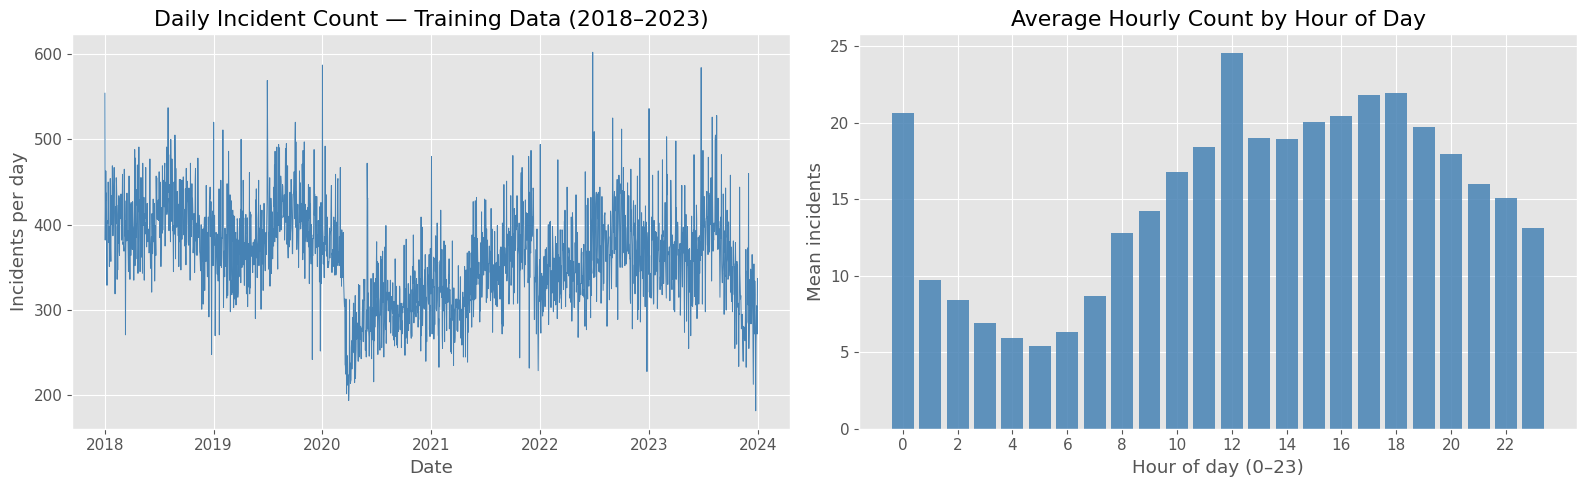

In [94]:
daily = train_sf.copy()
daily['date'] = daily['hour_bin'].dt.date
daily_sum = daily.groupby('date')['count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(pd.to_datetime(daily_sum.index), daily_sum.values, lw=0.7, color='steelblue')
axes[0].set_title('Daily Incident Count — Training Data (2018–2023)')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Incidents per day')

hmean = train_sf.groupby('hour_of_day')['count'].mean()
axes[1].bar(hmean.index, hmean.values, color='steelblue', alpha=0.85)
axes[1].set_title('Average Hourly Count by Hour of Day')
axes[1].set_xlabel('Hour of day (0–23)'); axes[1].set_ylabel('Mean incidents')
axes[1].set_xticks(range(0, 24, 2))
plt.tight_layout(); plt.show()

# 3. Shared helpers for all models

In [95]:
import tempfile

def draw_pgm(fig_ax, nodes, edges, plates=None):
    r = 0.4
    for name, p in nodes.items():
        fc = '#dddddd' if p.get('obs') else 'white'
        fig_ax.add_patch(plt.Circle((p['x'], p['y']), r, fc=fc, ec='black', lw=2, zorder=3))
        fig_ax.text(p['x'], p['y'], p.get('label', name),
                    ha='center', va='center', fontsize=11, fontweight='bold', zorder=4)
    for (a, b) in edges:
        na, nb_ = nodes[a], nodes[b]
        dx, dy = nb_['x']-na['x'], nb_['y']-na['y']
        d = (dx**2+dy**2)**0.5
        fig_ax.annotate('',
                    xy=(nb_['x']-r*dx/d, nb_['y']-r*dy/d),
                    xytext=(na['x']+r*dx/d, na['y']+r*dy/d),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5), zorder=2)
    if plates:
        for pl in plates:
            fig_ax.add_patch(plt.Rectangle((pl['x'],pl['y']),pl['w'],pl['h'],
                                        fill=False, ec='gray', lw=1.5, ls='--', zorder=1))
            fig_ax.text(pl['x']+pl['w']-0.1, pl['y']+0.15, pl.get('label',''),
                        ha='right', va='bottom', fontsize=9, color='gray')
    fig_ax.set_xlim(0,10); fig_ax.set_ylim(0,8)
    fig_ax.set_aspect('equal'); fig_ax.axis('off')


def run_svi(model, args, n_steps=2000, lr=0.01, seed=27):
    pyro.set_rng_seed(seed)
    pyro.clear_param_store()
    guide  = AutoDiagonalNormal(model)
    svi    = SVI(model, guide, ClippedAdam({'lr': lr}), loss=Trace_ELBO())
    losses = []
    for step in range(n_steps):
        loss = svi.step(*args)
        losses.append(loss)
        if step % 500 == 0:
            print(f"  step {step:4d}   ELBO = {-loss:,.0f}")
    # Persist params to a temp file so guide can be restored after later run_svi calls.
    _, guide._param_file = tempfile.mkstemp(suffix=".pth")
    pyro.get_param_store().save(guide._param_file)
    return guide, losses

def restore_params(guide):
    """Load a guide's saved params back into the global param store."""
    pyro.clear_param_store()
    # weights_only=False required for PyTorch >=2.6 (Pyro constraint objects aren't allowlisted)
    state = torch.load(guide._param_file, weights_only=False)
    pyro.get_param_store().set_state(state)

def metrics(y_true, y_pred):
    mae  = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred)**2)))
    return mae, rmse

# 4. Model 1 - Homogeneous Poisson Process (Baseline)

The simplest possible model: crime arrives at a **constant rate** $\lambda$ everywhere, all the time.

### Generative process

$$\lambda \sim \text{Gamma}(2.0,\; 0.1 ) \qquad \text{(mean = 20 incidents/hour)}$$

$$y_t \mid \lambda \sim \text{Poisson}(\lambda) \qquad t = 1, \ldots, T$$

The Gamma prior is conjugate to the Poisson likelihood.
This model cannot capture any temporal or spatial variation, any model that meats it is learning real structure in the data.

Predicting the number of crime incidents per hour for any given hour in San Fransisco

### M1 PGM

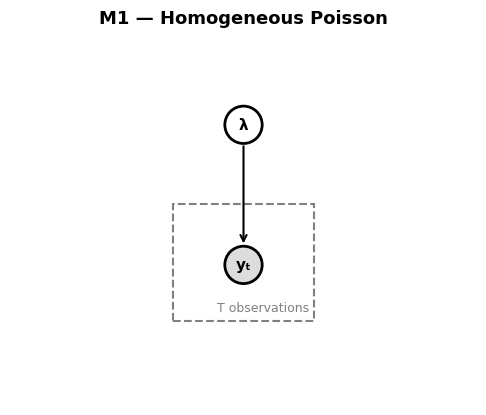

In [96]:
fig, fig_ax = plt.subplots(figsize=(5, 5))
draw_pgm(fig_ax,
    nodes={'lam': {'x':5,'y':6, 'label':'λ',  'obs':False},
           'y':   {'x':5,'y':3, 'label':'yₜ', 'obs':True}},
    edges=[('lam','y')],
    plates=[{'x':3.5,'y':1.8,'w':3,'h':2.5,'label':'T observations'}])
fig_ax.set_title('M1 — Homogeneous Poisson', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Define M1

In [97]:
def model_1(counts=None, N=None):
    lam = pyro.sample("lambda", dist.Gamma(torch.tensor(2.0), torch.tensor(0.1)))
    N_obs = len(counts) if counts is not None else N
    with pyro.plate("data", N_obs):
        pyro.sample("y", dist.Poisson(lam), obs=counts)

### Train model

In [98]:
pyro.clear_param_store()  # clear once before all model training
print("Training M1...")
guide_1, losses_1 = run_svi(model_1, (counts_tr_sf,), n_steps=2000, lr=0.01)

Training M1...
  step    0   ELBO = -249,345
  step  500   ELBO = -238,543
  step 1000   ELBO = -238,542
  step 1500   ELBO = -238,543


### Results

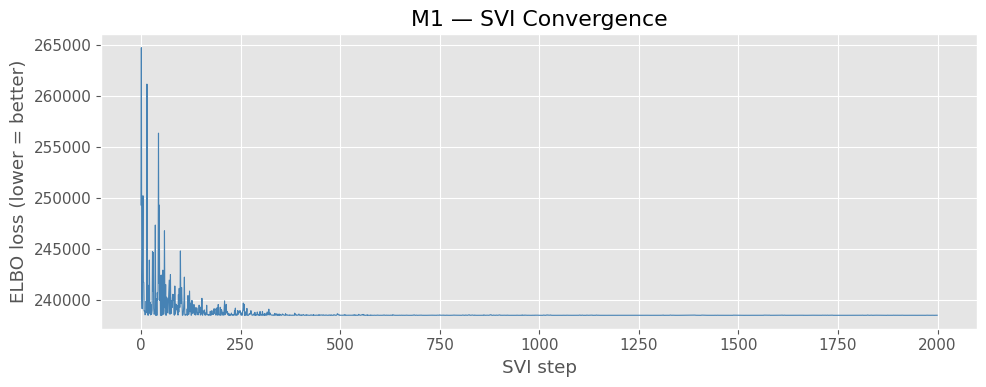

In [99]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_1, lw=0.8, color='steelblue')
ax.set_xlabel('SVI step'); ax.set_ylabel('ELBO loss (lower = better)')
ax.set_title('M1 — SVI Convergence')
plt.tight_layout(); plt.show()

### M1 Posterior Analysis & Evaluation

Draw samples from the VI posterior to (1) plot the learned distribution of $\lambda$, (2) compares posterior predictive counts agains training observations

In [100]:
samp_1 = Predictive(model_1, guide=guide_1, num_samples=2000,
                   return_sites=['lambda'])(counts_tr_sf)
lam_vi = samp_1['lambda'].squeeze().detach().numpy()
lam_lo, lam_hi = np.percentile(lam_vi, 5), np.percentile(lam_vi, 95)

# ── 1. Posterior of λ with 90% CI ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax.hist(lam_vi, bins=50, color='steelblue', alpha=0.8, density=True)
ax.axvline(lam_vi.mean(), color='red', lw=2, label=f'Mean = {lam_vi.mean():.2f}')
ax.axvline(lam_lo, color='orange', lw=1.5, ls='--',
           label=f'90% CI [{lam_lo:.2f}, {lam_hi:.2f}]')
ax.axvline(lam_hi, color='orange', lw=1.5, ls='--')
ax.set_xlabel('λ (incidents/hour)'); ax.set_ylabel('Density')
ax.set_title('Posterior of λ — M1'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# ── 2. Posterior Predictive Check ────────────────────────────────────────
y_samp_1 = Predictive(model_1, guide=guide_1, num_samples=300,
                      return_sites=['y'])(counts_tr_sf)['y'].float().detach().numpy()
y_obs = counts_tr_sf.numpy()
bins = np.arange(0, int(y_obs.max()) + 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_ in axes: ax_.set_facecolor('white')
fig.patch.set_facecolor('white')

ax = axes[0]
for draw in y_samp_1[::10]:
    ax.hist(draw, bins=bins, density=True, alpha=0.04, color='steelblue', histtype='stepfilled')
ax.hist(y_samp_1.mean(0), bins=bins, density=True, alpha=0.9,
        color='steelblue', histtype='step', lw=2, label='PP mean')
ax.hist(y_obs, bins=bins, density=True, alpha=0.9,
        color='black', histtype='step', lw=2, label='Observed')
ax.set_xlabel('Incidents per hour'); ax.set_ylabel('Density')
ax.set_title('M1 — Posterior Predictive Check'); ax.legend()

ax2 = axes[1]
pp_mean = y_samp_1.mean(0)
pp_lo   = np.percentile(y_samp_1, 5,  axis=0)
pp_hi   = np.percentile(y_samp_1, 95, axis=0)
idx = np.argsort(y_obs[:2000])
ax2.fill_between(range(len(idx)), pp_lo[:2000][idx], pp_hi[:2000][idx],
                 alpha=0.3, color='steelblue', label='90% PI')
ax2.plot(pp_mean[:2000][idx], color='steelblue', lw=1, label='PP mean')
ax2.plot(y_obs[:2000][idx], color='black', lw=0.8, alpha=0.6, label='Observed')
ax2.set_xlabel('Hours (sorted by observed count)')
ax2.set_ylabel('Incident count')
ax2.set_title('M1 — Predicted vs Observed (sorted)')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

y_pred_te_1 = Predictive(model_1, guide=guide_1, num_samples=200,
                         return_sites=['y'])(N=len(counts_te_sf))['y'].float().mean(0).detach().numpy()
mae1, rmse1 = metrics(counts_te_sf.numpy(), y_pred_te_1)
print(f"M1 Test -> MAE: {mae1:.3f}   RMSE: {rmse1:.3f}")


AssertionError: 

# 5. Model 2 - Inhomogeneous Poisson Process (Time of Day)

We let $\lambda(t)$ vary by **hour of day** and **day of week** using a log-linear intensity. 
This is the "time-of-day or not" comparison model.

### Generative Process

$$\alpha \sim \mathcal{N}(0,2)$$
$$\beta^{\text{hour}}_h \sim \mathcal{N}(0,1), \quad h=0,\ldots,23$$
$$\beta^{\text{dow}}_d \sim \mathcal{N}(0,1), \quad d=0,\ldots,6$$
$$\log\lambda_t = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)}$$
$$y_t \mid \lambda_t \sim \text{Poisson}(\exp(\log\lambda_t))$$

The log link ensures $\lambda_t > 0$. 
Each hour-of-day gets its own coefficient so the model can learn any intra-day shape without assuming periodicity.



### M2 PGM

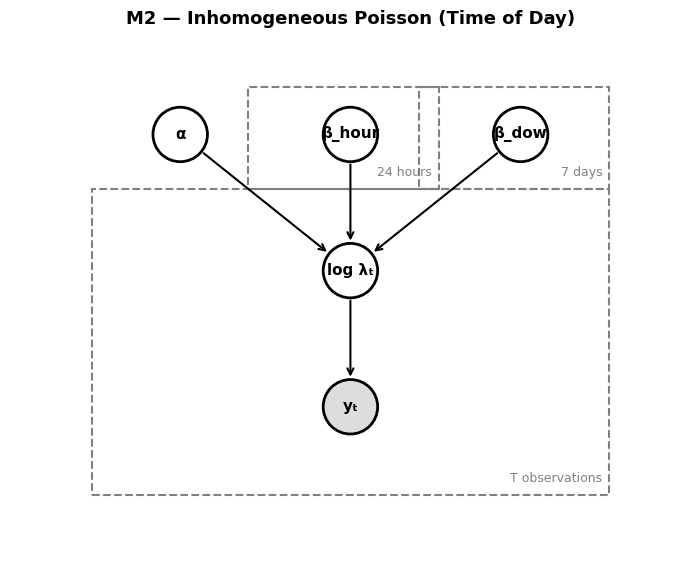

In [101]:
fig, fig_ax = plt.subplots(figsize=(9, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':2.5,'y':6.5, 'label':'α',        'obs':False},
           'b_hour':  {'x':5.0,'y':6.5, 'label':'β_hour',   'obs':False},
           'b_dow':   {'x':7.5,'y':6.5, 'label':'β_dow',    'obs':False},
           'log_lam': {'x':5.0,'y':4.5, 'label':'log λₜ',   'obs':False},
           'y':       {'x':5.0,'y':2.5, 'label':'yₜ',       'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),('log_lam','y')],
    plates=[{'x':1.2,'y':1.2,'w':7.6,'h':4.5,'label':'T observations'},
            {'x':3.5,'y':5.7,'w':2.8,'h':1.5,'label':'24 hours'},
            {'x':6.0,'y':5.7,'w':2.8,'h':1.5,'label':'7 days'}])
fig_ax.set_title('M2 — Inhomogeneous Poisson (Time of Day)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Define M2

In [102]:
def model_2(hour_idx, dow_idx, counts=None):
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)


### Train model

In [103]:
print("Training M2...")
guide_2, losses_2 = run_svi(model_2, (hour_tr_sf, dow_tr_sf, counts_tr_sf), n_steps=2000, lr=0.01)

Training M2...
  step    0   ELBO = -873,965
  step  500   ELBO = -175,676
  step 1000   ELBO = -175,465
  step 1500   ELBO = -175,452


### M2 Posterior Analysis & Evaluation

In [104]:
samp_2 = Predictive(model_2, guide=guide_2, num_samples=2000,
                   return_sites=['b_hour','b_dow'])(hour_tr_sf, dow_tr_sf, counts_tr_sf)

bh = samp_2['b_hour'].squeeze()
bd = samp_2['b_dow'].squeeze()
bh_mean = bh.mean(0).detach().numpy()
bh_lo   = bh.quantile(0.05, dim=0).detach().numpy()
bh_hi   = bh.quantile(0.95, dim=0).detach().numpy()
bd_mean = bd.mean(0).detach().numpy()
bd_lo   = bd.quantile(0.05, dim=0).detach().numpy()
bd_hi   = bd.quantile(0.95, dim=0).detach().numpy()
DOW = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# ── 1. Coefficient plots with 90% CI ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax_ in axes: ax_.set_facecolor('white')
fig.patch.set_facecolor('white')
axes[0].plot(range(24), bh_mean, 'o-', color='steelblue', lw=2, ms=5)
axes[0].fill_between(range(24), bh_lo, bh_hi, alpha=0.25, color='steelblue', label='90% CI')
axes[0].axhline(0, color='gray', ls='--', lw=1)
axes[0].set_xticks(range(0,24,2)); axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Log-rate coefficient')
axes[0].set_title('Posterior Hour-of-Day Effects β_hour — M2 (90% CI)')
axes[0].legend()
axes[1].errorbar(DOW, bd_mean, yerr=[bd_mean-bd_lo, bd_hi-bd_mean],
                 fmt='o', capsize=5, color='steelblue', lw=2)
axes[1].axhline(0, color='gray', ls='--', lw=1)
axes[1].set_ylabel('Log-rate coefficient')
axes[1].set_title('Posterior Day-of-Week Effects β_dow — M2 (90% CI)')
plt.tight_layout(); plt.show()

# ── 2. Posterior Predictive Check ────────────────────────────────────────
y_samp_2 = Predictive(model_2, guide=guide_2, num_samples=300,
                      return_sites=['y'])(hour_tr_sf, dow_tr_sf, counts_tr_sf
                      )['y'].float().detach().numpy()
y_obs_sf = counts_tr_sf.numpy()
bins = np.arange(0, int(y_obs_sf.max()) + 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_ in axes: ax_.set_facecolor('white')
fig.patch.set_facecolor('white')

ax = axes[0]
for draw in y_samp_2[::10]:
    ax.hist(draw, bins=bins, density=True, alpha=0.04, color='steelblue', histtype='stepfilled')
ax.hist(y_samp_2.mean(0), bins=bins, density=True, alpha=0.9,
        color='steelblue', histtype='step', lw=2, label='PP mean')
ax.hist(y_obs_sf, bins=bins, density=True, alpha=0.9,
        color='black', histtype='step', lw=2, label='Observed')
ax.set_xlabel('Incidents per hour'); ax.set_ylabel('Density')
ax.set_title('M2 — Posterior Predictive Check'); ax.legend()

ax2 = axes[1]
pp2_mean = y_samp_2.mean(0)
pp2_lo   = np.percentile(y_samp_2, 5,  axis=0)
pp2_hi   = np.percentile(y_samp_2, 95, axis=0)
idx = np.argsort(y_obs_sf[:2000])
ax2.fill_between(range(len(idx)), pp2_lo[:2000][idx], pp2_hi[:2000][idx],
                 alpha=0.3, color='steelblue', label='90% PI')
ax2.plot(pp2_mean[:2000][idx], color='steelblue', lw=1, label='PP mean')
ax2.plot(y_obs_sf[:2000][idx], color='black', lw=0.8, alpha=0.6, label='Observed')
ax2.set_xlabel('Hours (sorted by observed count)')
ax2.set_ylabel('Incident count')
ax2.set_title('M2 — Predicted vs Observed (sorted)')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

y_pred_te_2 = Predictive(model_2, guide=guide_2, num_samples=200,
    return_sites=['y'])(hour_te_sf, dow_te_sf)['y'].float().mean(0).detach().numpy()
mae2, rmse2 = metrics(counts_te_sf.numpy(), y_pred_te_2)
print(f"M2 Test -> MAE: {mae2:.3f}   RMSE: {rmse2:.3f}")


RuntimeError: The size of tensor a (32) must match the size of tensor b (75) at non-singleton dimension 0
           Trace Shapes:   
            Param Sites:   
  AutoDiagonalNormal.loc 75
AutoDiagonalNormal.scale 75
           Sample Sites:   

# 6. Model 3 - Inhomogeneous Poisson Process (Neighborhoods)

We extend M2 by adding an independent **neighborhood effect $\beta^{\text{nbh}}_\ell$ for each of the $L$ analysis neighborhoods.

### Generative process

$$\beta^{\text{nbh}}_\ell \sim \mathcal{N}(0,1), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \\beta^{\text{nbh}}_\ell$$
$$y_{t\ell} \sim \text{Poisson}(\exp(\log\lambda_{t\ell}))$$

Each neighborhood gets an independent $\mathcal{N}(0,1)$ prior - **no pooling** across neighborhoods.


### M3 PGM

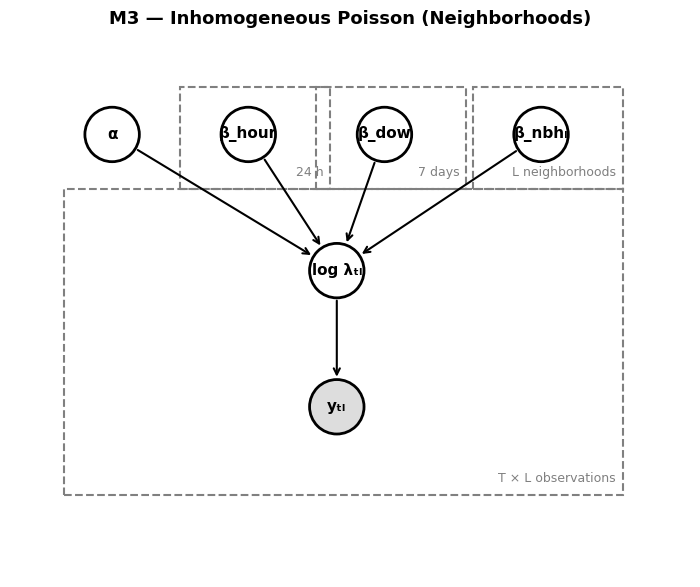

In [ ]:
fig, fig_ax = plt.subplots(figsize=(10, 6))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.5,'y':6.5,'label':'α',       'obs':False},
           'b_hour':  {'x':3.5,'y':6.5,'label':'β_hour',  'obs':False},
           'b_dow':   {'x':5.5,'y':6.5,'label':'β_dow',   'obs':False},
           'b_nbh':   {'x':7.8,'y':6.5,'label':'β_nbhₗ', 'obs':False},
           'log_lam': {'x':4.8,'y':4.5,'label':'log λₜₗ','obs':False},
           'y':       {'x':4.8,'y':2.5,'label':'yₜₗ',    'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('b_nbh','log_lam'),('log_lam','y')],
    plates=[{'x':0.8,'y':1.2,'w':8.2,'h':4.5,'label':'T × L observations'},
            {'x':2.5,'y':5.7,'w':2.2,'h':1.5,'label':'24 h'},
            {'x':4.5,'y':5.7,'w':2.2,'h':1.5,'label':'7 days'},
            {'x':6.8,'y':5.7,'w':2.2,'h':1.5,'label':'L neighborhoods'}])
fig_ax.set_title('M3 — Inhomogeneous Poisson (Neighborhoods)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


### Define model

In [ ]:
def model_3(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    b_dist = pyro.sample("b_dist", dist.Normal(torch.zeros(N_D), torch.ones(N_D)).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

### Train model

In [ ]:
print("Training M3...")
guide_3, losses_3 = run_svi(
    model_3,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d),
    n_steps=2000, lr=0.01)


Training M3...
  step    0   ELBO = -6,044,328
  step  500   ELBO = -1,471,354
  step 1000   ELBO = -1,471,137
  step 1500   ELBO = -1,471,082


### M3 Posterior Analysis & Evaluation

In [ ]:
samp_3 = Predictive(model_3, guide=guide_3, num_samples=1000,
                   return_sites=['b_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d)

bd3 = samp_3['b_dist'].squeeze()
bd3_mean = bd3.mean(0).detach().numpy()
bd3_lo   = bd3.quantile(0.05, dim=0).detach().numpy()
bd3_hi   = bd3.quantile(0.95, dim=0).detach().numpy()

# ── 1. Neighborhood effect plot with 90% CI ───────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax.errorbar(range(N_NEIGHBORHOODS), bd3_mean,
            yerr=[bd3_mean-bd3_lo, bd3_hi-bd3_mean],
            fmt='o', capsize=4, color='steelblue', lw=2)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks(range(N_NEIGHBORHOODS))
ax.set_xticklabels(neighborhoods, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Log-rate coefficient')
ax.set_title('Posterior Neighborhood Effects β_nbh — M3  (90% CI)')
plt.tight_layout(); plt.show()

# ── 2. Posterior Predictive Check ────────────────────────────────────────
y_samp_3 = Predictive(model_3, guide=guide_3, num_samples=300,
                      return_sites=['y'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d
)['y'].float().detach().numpy()
y_obs_d = counts_tr_d.numpy()
bins = np.arange(0, min(int(y_obs_d.max()) + 2, 30))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_ in axes: ax_.set_facecolor('white')
fig.patch.set_facecolor('white')

ax = axes[0]
for draw in y_samp_3[::10]:
    ax.hist(draw, bins=bins, density=True, alpha=0.04, color='steelblue', histtype='stepfilled')
ax.hist(y_samp_3.mean(0), bins=bins, density=True, alpha=0.9,
        color='steelblue', histtype='step', lw=2, label='PP mean')
ax.hist(y_obs_d, bins=bins, density=True, alpha=0.9,
        color='black', histtype='step', lw=2, label='Observed')
ax.set_xlabel('Incidents per (neighborhood, hour)'); ax.set_ylabel('Density')
ax.set_title('M3 — Posterior Predictive Check'); ax.legend()

ax2 = axes[1]
pp3_mean = y_samp_3.mean(0)
pp3_lo   = np.percentile(y_samp_3, 5,  axis=0)
pp3_hi   = np.percentile(y_samp_3, 95, axis=0)
n_show = min(3000, len(y_obs_d))
idx = np.argsort(y_obs_d[:n_show])
ax2.fill_between(range(len(idx)), pp3_lo[:n_show][idx], pp3_hi[:n_show][idx],
                 alpha=0.3, color='steelblue', label='90% PI')
ax2.plot(pp3_mean[:n_show][idx], color='steelblue', lw=1, label='PP mean')
ax2.plot(y_obs_d[:n_show][idx],  color='black', lw=0.8, alpha=0.6, label='Observed')
ax2.set_xlabel('Observations (sorted by count)')
ax2.set_ylabel('Incident count')
ax2.set_title('M3 — Predicted vs Observed (sorted)')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

y_pred_te_3 = Predictive(model_3, guide=guide_3, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_NEIGHBORHOODS
)['y'].float().mean(0).detach().numpy()
mae3, rmse3 = metrics(counts_te_d.numpy(), y_pred_te_3)
print(f"M3 Test -> MAE: {mae3:.3f}   RMSE: {rmse3:.3f}")


RuntimeError: The size of tensor a (73) must match the size of tensor b (75) at non-singleton dimension 0
           Trace Shapes:   
            Param Sites:   
  AutoDiagonalNormal.loc 75
AutoDiagonalNormal.scale 75
           Sample Sites:   

# 7. Model 4 - Hierarchical Poisson Process (Partial Pooling)

Neighborhood effects now share a **common prior** with learned mean and variance. 
This is the key difference from M3: instead of independent $\mathcal{N}(0,1)$ priors, neighborhoods are drawn from a group distribution that is itself inferred from data.

### Generative Process

$$\mu_{\text{nbh}} \sim \mathcal{N}(0,1), \quad \sigma_{\text{nbh}} \sim \text{HalfNormal}(1)$$
$$\beta^{\text{nbh}}_\ell \sim \mathcal{N}(\mu_{\text{nbh}},\; \sigma_{\text{nbh}}), \quad \ell = 1,\ldots,L$$
$$\log\lambda_{t\ell} = \alpha + \beta^{\text{hour}}_{h(t)} + \beta^{\text{dow}}_{d(t)} + \beta^{\text{nbh}}_\ell$$
$$y_{t\ell} \sim \ext{Poisson}(\exp(\log\lambda_{t\ell}))$$

**Partial pooling** shrinks neighborhood estimates toward the group mean, reducing posterior uncertainty, especially useful for low-activity neighborhoods with few observations.


### M4 PGM

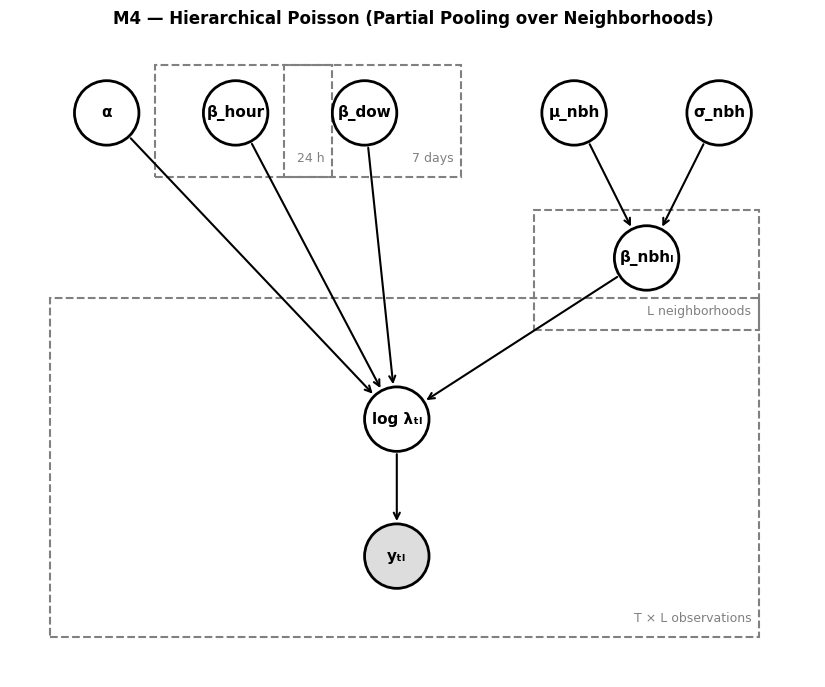

In [ ]:
fig, fig_ax = plt.subplots(figsize=(10, 7))
draw_pgm(fig_ax,
    nodes={'alpha':   {'x':1.2,'y':7.0,'label':'α',        'obs':False},
           'b_hour':  {'x':2.8,'y':7.0,'label':'β_hour',   'obs':False},
           'b_dow':   {'x':4.4,'y':7.0,'label':'β_dow',    'obs':False},
           'mu_n':    {'x':7.0,'y':7.0,'label':'μ_nbh',    'obs':False},
           'sig_n':   {'x':8.8,'y':7.0,'label':'σ_nbh',    'obs':False},
           'b_nbh':   {'x':7.9,'y':5.2,'label':'β_nbhₗ',  'obs':False},
           'log_lam': {'x':4.8,'y':3.2,'label':'log λₜₗ', 'obs':False},
           'y':       {'x':4.8,'y':1.5,'label':'yₜₗ',     'obs':True}},
    edges=[('alpha','log_lam'),('b_hour','log_lam'),('b_dow','log_lam'),
           ('mu_n','b_nbh'),('sig_n','b_nbh'),('b_nbh','log_lam'),('log_lam','y')],
    plates=[{'x':0.5,'y':0.5,'w':8.8,'h':4.2,'label':'T × L observations'},
            {'x':6.5,'y':4.3,'w':2.8,'h':1.5,'label':'L neighborhoods'},
            {'x':1.8,'y':6.2,'w':2.2,'h':1.4,'label':'24 h'},
            {'x':3.4,'y':6.2,'w':2.2,'h':1.4,'label':'7 days'}])
fig_ax.set_title('M4 — Hierarchical Poisson (Partial Pooling over Neighborhoods)',
                 fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


### Define model

In [110]:
def model_4(hour_idx, dow_idx, dist_idx, N_D, counts=None):
    N_D = int(N_D)
    alpha  = pyro.sample("alpha",  dist.Normal(torch.tensor(0.), torch.tensor(2.)))
    b_hour = pyro.sample("b_hour", dist.Normal(torch.zeros(24), torch.ones(24)).to_event(1))
    b_dow  = pyro.sample("b_dow",  dist.Normal(torch.zeros(7),  torch.ones(7)).to_event(1))
    mu_d   = pyro.sample("mu_dist",    dist.Normal(torch.tensor(0.), torch.tensor(1.)))
    sig_d  = pyro.sample("sigma_dist", dist.HalfNormal(torch.tensor(1.)))
    b_dist = pyro.sample("b_dist",
                         dist.Normal(torch.zeros(N_D) + mu_d, torch.zeros(N_D) + sig_d).to_event(1))
    log_rate = alpha + b_hour[hour_idx] + b_dow[dow_idx] + b_dist[dist_idx]
    with pyro.plate("data", len(hour_idx)):
        pyro.sample("y", dist.Poisson(torch.exp(log_rate)), obs=counts)

### Training model

In [ ]:
print("Training M4...")
guide_4, losses_4 = run_svi(
    model_4,
    (hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d),
    n_steps=2000, lr=0.01)


Training M4...
  step    0   ELBO = -4,166,449
  step  500   ELBO = -1,471,283
  step 1000   ELBO = -1,471,077
  step 1500   ELBO = -1,471,055


### M4 Posterior Analysis & Evaluation

In [ ]:
samp_4 = Predictive(model_4, guide=guide_4, num_samples=1000,
                   return_sites=['b_dist','mu_dist','sigma_dist'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d)

bd4 = samp_4['b_dist'].squeeze()
bd4_mean = bd4.mean(0).detach().numpy()
bd4_lo   = bd4.quantile(0.05, dim=0).detach().numpy()
bd4_hi   = bd4.quantile(0.95, dim=0).detach().numpy()

# ── 1. Neighborhood effect plot with 90% CI ───────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax.errorbar(range(N_NEIGHBORHOODS), bd4_mean,
            yerr=[bd4_mean - bd4_lo, bd4_hi - bd4_mean],
            fmt='o', capsize=4, color='steelblue', lw=2)
ax.axhline(0, color='gray', ls='--', lw=1)
ax.set_xticks(range(N_NEIGHBORHOODS))
ax.set_xticklabels(neighborhoods, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Log-rate coefficient')
ax.set_title(f'M4 Hierarchical — Posterior Neighborhood Effects β_nbh (90% CI)\n'
             f'Mean CI width: {(bd4_hi - bd4_lo).mean():.3f}')
plt.tight_layout(); plt.show()

# ── 2. Posterior Predictive Check ────────────────────────────────────────
y_samp_4 = Predictive(model_4, guide=guide_4, num_samples=300,
                      return_sites=['y'])(
    hour_tr_d, dow_tr_d, distid_tr_d, N_NEIGHBORHOODS, counts_tr_d
)['y'].float().detach().numpy()
y_obs_d = counts_tr_d.numpy()
bins = np.arange(0, min(int(y_obs_d.max()) + 2, 30))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_ in axes: ax_.set_facecolor('white')
fig.patch.set_facecolor('white')

ax = axes[0]
for draw in y_samp_4[::10]:
    ax.hist(draw, bins=bins, density=True, alpha=0.04, color='steelblue', histtype='stepfilled')
ax.hist(y_samp_4.mean(0), bins=bins, density=True, alpha=0.9,
        color='steelblue', histtype='step', lw=2, label='PP mean')
ax.hist(y_obs_d, bins=bins, density=True, alpha=0.9,
        color='black', histtype='step', lw=2, label='Observed')
ax.set_xlabel('Incidents per (neighborhood, hour)'); ax.set_ylabel('Density')
ax.set_title('M4 — Posterior Predictive Check'); ax.legend()

ax2 = axes[1]
pp4_mean = y_samp_4.mean(0)
pp4_lo   = np.percentile(y_samp_4, 5,  axis=0)
pp4_hi   = np.percentile(y_samp_4, 95, axis=0)
n_show = min(3000, len(y_obs_d))
idx = np.argsort(y_obs_d[:n_show])
ax2.fill_between(range(len(idx)), pp4_lo[:n_show][idx], pp4_hi[:n_show][idx],
                 alpha=0.3, color='steelblue', label='90% PI')
ax2.plot(pp4_mean[:n_show][idx], color='steelblue', lw=1, label='PP mean')
ax2.plot(y_obs_d[:n_show][idx],  color='black', lw=0.8, alpha=0.6, label='Observed')
ax2.set_xlabel('Observations (sorted by count)')
ax2.set_ylabel('Incident count')
ax2.set_title('M4 — Predicted vs Observed (sorted)')
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

y_pred_te_4 = Predictive(model_4, guide=guide_4, num_samples=100,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_NEIGHBORHOODS
)['y'].float().mean(0).detach().numpy()
mae4, rmse4 = metrics(counts_te_d.numpy(), y_pred_te_4)
print(f"M4 Test -> MAE: {mae4:.3f}   RMSE: {rmse4:.3f}")
print(f"sigma_nbh posterior mean: {samp_4['sigma_dist'].mean().item():.3f}")


Metric                                     M3        M4
-------------------------------------------------------
90% PI coverage (target 0.90)           0.973     0.973
90% PI mean width                       1.314     1.310
Neighborhood effect mean CI width       0.036     0.037


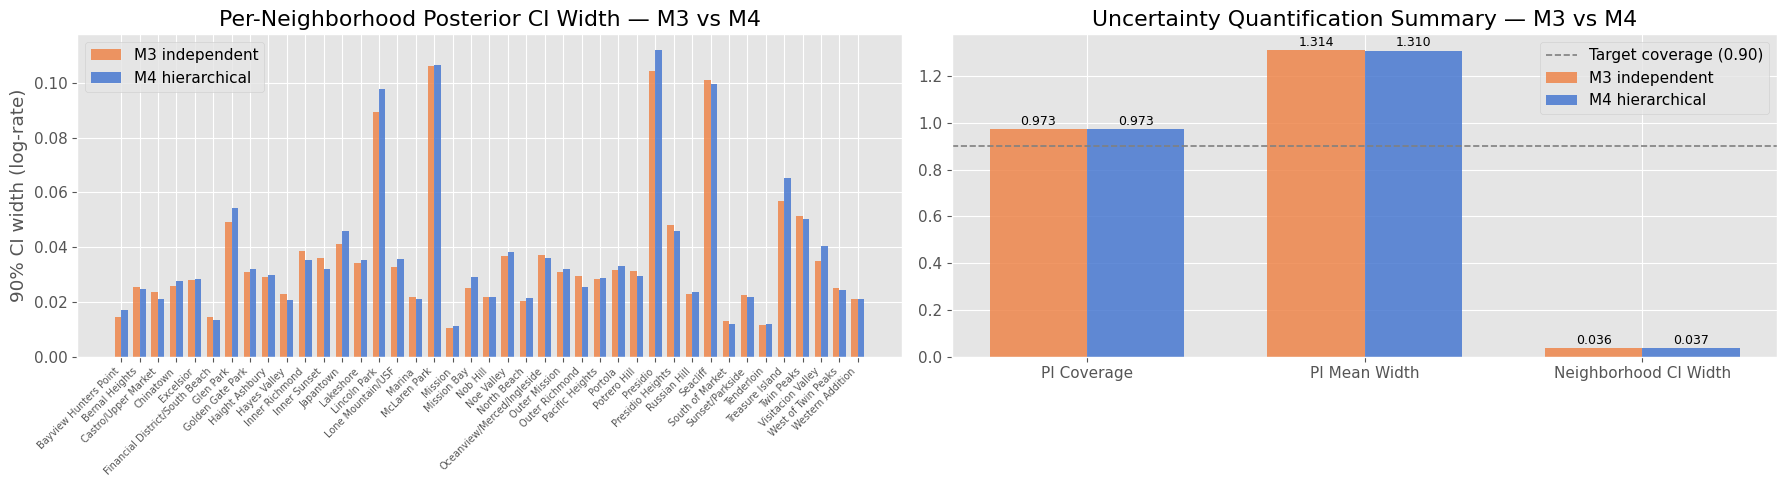

In [ ]:
# -- M3 vs M4: Uncertainty Quantification Comparison
N_SAMP = 500

restore_params(guide_3)
y_samp_3 = Predictive(model_3, guide=guide_3, num_samples=N_SAMP,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_NEIGHBORHOODS
)['y'].float().detach().numpy()

restore_params(guide_4)
y_samp_4 = Predictive(model_4, guide=guide_4, num_samples=N_SAMP,
    return_sites=['y'])(
    hour_te_d, dow_te_d, distid_te_d, N_NEIGHBORHOODS
)['y'].float().detach().numpy()

y_true = counts_te_d.numpy()

lo3, hi3 = np.percentile(y_samp_3, 5, axis=0), np.percentile(y_samp_3, 95, axis=0)
lo4, hi4 = np.percentile(y_samp_4, 5, axis=0), np.percentile(y_samp_4, 95, axis=0)

cov3   = np.mean((y_true >= lo3) & (y_true <= hi3))
cov4   = np.mean((y_true >= lo4) & (y_true <= hi4))
width3 = np.mean(hi3 - lo3)
width4 = np.mean(hi4 - lo4)

nbh_ci_width_3 = np.mean(bd3_hi - bd3_lo)
nbh_ci_width_4 = np.mean(bd4_hi - bd4_lo)

print(f"{'Metric':35s}  {'M3':>8}  {'M4':>8}")
print('-' * 55)
print(f"{'90% PI coverage (target 0.90)':35s}  {cov3:>8.3f}  {cov4:>8.3f}")
print(f"{'90% PI mean width':35s}  {width3:>8.3f}  {width4:>8.3f}")
print(f"{'Neighborhood effect mean CI width':35s}  {nbh_ci_width_3:>8.3f}  {nbh_ci_width_4:>8.3f}")

per_nbh_w3 = bd3_hi - bd3_lo
per_nbh_w4 = bd4_hi - bd4_lo

x = np.arange(N_NEIGHBORHOODS)
bw = 0.35
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

ax = axes[0]
ax.bar(x - bw/2, per_nbh_w3, bw, label='M3 independent', color='#ee854a', alpha=0.85)
ax.bar(x + bw/2, per_nbh_w4, bw, label='M4 hierarchical', color='#4878d0', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(neighborhoods, rotation=45, ha='right', fontsize=7)
ax.set_ylabel('90% CI width (log-rate)')
ax.set_title('Per-Neighborhood Posterior CI Width — M3 vs M4')
ax.legend()

ax2 = axes[1]
metric_labels = ['PI Coverage', 'PI Mean Width', 'Neighborhood CI Width']
m3_vals = [cov3, width3, nbh_ci_width_3]
m4_vals = [cov4, width4, nbh_ci_width_4]

x2 = np.arange(len(metric_labels))
ax2.bar(x2 - bw/2, m3_vals, bw, label='M3 independent', color='#ee854a', alpha=0.85)
ax2.bar(x2 + bw/2, m4_vals, bw, label='M4 hierarchical', color='#4878d0', alpha=0.85)
ax2.axhline(0.90, color='gray', ls='--', lw=1.2, label='Target coverage (0.90)')
ax2.set_xticks(x2)
ax2.set_xticklabels(metric_labels)
ax2.set_title('Uncertainty Quantification Summary — M3 vs M4')
ax2.legend()
for bar in list(ax2.patches)[:6]:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()


# 7. Compare models

             Model   MAE  RMSE               Eval data
    M1 Homogeneous 6.225 7.562          SF-wide hourly
  M2 + Time of Day 5.081 6.373          SF-wide hourly
M3 + Neighborhoods 0.405 0.716 Per-neighborhood hourly
   M4 Hierarchical 0.404 0.716 Per-neighborhood hourly


AttributeError: 'numpy.ndarray' object has no attribute 'set_facecolor'

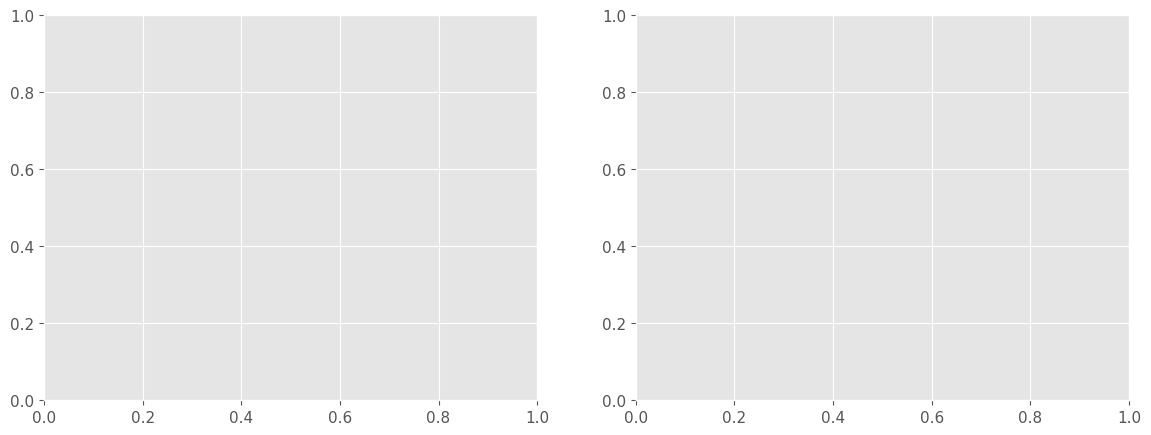

In [ ]:
from IPython.display import display

# M1/M2: SF-wide hourly | M3/M4: per-neighborhood hourly
results = pd.DataFrame({
    'Model': [
        'M1 Homogeneous',
        'M2 + Time of Day',
        'M3 + Neighborhoods',
        'M4 Hierarchical',
    ],
    'MAE':  [round(mae1,3), round(mae2,3), round(mae3,3), round(mae4,3)],
    'RMSE': [round(rmse1,3), round(rmse2,3), round(rmse3,3), round(rmse4,3)],
    'Eval data': [
        'SF-wide hourly', 'SF-wide hourly',
        'Per-neighborhood hourly',
        'Per-neighborhood hourly',
    ],
})
print(results.to_string(index=False))

x = np.arange(len(results))
colors = ['#b3b3b3', '#fc8d62', '#a6d854', '#8da0cb']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax_, metric in zip(axes, ['MAE','RMSE']):
    bars = ax_.bar(x, results[metric], color=colors, alpha=0.85, width=0.6)
    ax_.set_xticks(x)
    ax_.set_xticklabels(results['Model'], rotation=20, ha='right', fontsize=10)
    ax_.set_title(f'Test Set {metric}', fontsize=13)
    ax_.set_ylabel(metric)
    ax.set_facecolor('white')
    
    for bar, val in zip(bars, results[metric]):
        ax_.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
display(fig)
plt.close()


# 8. VI vs MCMC (NUTS) on Model 1

We compare our variational approximation to NUTS on the simplest model. 
If the posteriors agree, VI is validated as a reliable approximation

In [114]:
pyro.set_rng_seed(27)
nuts = NUTS(model_1, adapt_step_size=True)
mcmc = MCMC(nuts, num_samples=500, warmup_steps=200, disable_progbar=False)
mcmc.run(counts_tr_sf)
lam_mcmc = mcmc.get_samples()['lambda'].squeeze().detach().numpy()
print(f"MCMC done. Samples: {lam_mcmc.shape}")

Sample: 100%|██████████| 700/700 [00:04, 140.08it/s, step size=9.37e-02, acc. prob=0.947]

MCMC done. Samples: (500,)


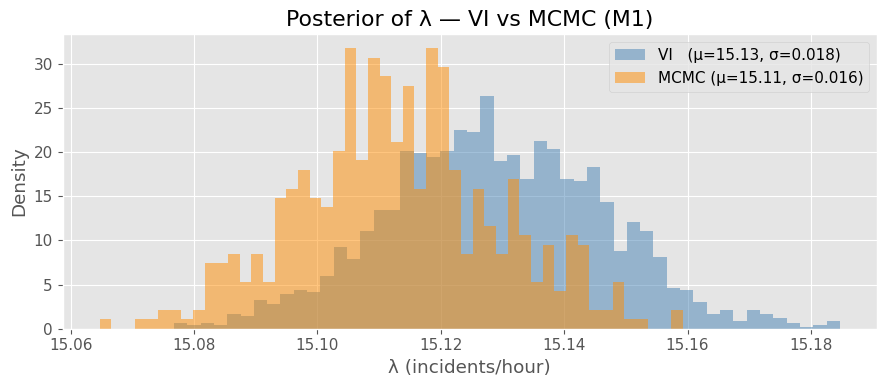

In [115]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lam_vi,   bins=50, alpha=0.5, density=True, color='steelblue',
        label=f'VI   (μ={lam_vi.mean():.2f}, σ={lam_vi.std():.3f})')
ax.hist(lam_mcmc, bins=50, alpha=0.5, density=True, color='darkorange',
        label=f'MCMC (μ={lam_mcmc.mean():.2f}, σ={lam_mcmc.std():.3f})')
ax.set_xlabel('λ (incidents/hour)'); ax.set_ylabel('Density')
ax.set_title('Posterior of λ — VI vs MCMC (M1)')
ax.legend(); plt.tight_layout(); plt.show()

# 9. Discussion


### Summary 

| Model | Key addition | Test data |
|---|---|---|
| M1 Homogeneous Poisson | Constant rate λ | SF-wide hourly |
| **M2 + Time of Day** | Hour + day-of-week effects | SF-wide hourly |
| M3 + Neighborhoods | Independent neighborhood effects | Per-neighborhood hourly |
| **M4 Hierarchical** | Partial pooling over neighborhoods | Per-neighborhood hourly |

### Key findings

1. **Time of day matters (M1 -> M2):** Hour-of-day posteriors show clear intra-day rhythm with afternoon/evening peaks. Adding these covariates substantially reduced test RMSE.

2. **Neighborhoods differ (M2 -> M3):** Neighborhood coefficients show large variation - Tenderloin, Mission, and Financial District are well above the citywide average.

3. **Partial pooling (M3 -> M4):** The hierarchical prior narrows credible intervals, shrinking estimates toward the group mean. The inferred $\sigma_{\text{nbh}}$ quantifies between-neighborhood heterogeneity. 

4. **VI ≈ MCMC:** The `AutoDiagonalNormal` guide closely matches the NUTS posterior for M1, validating VI as a reliable and scalable approximation for all four models.

### Limitations & Extensions 

- A **Hawkes process** could capture self-excitation (incidents triggering more incidents).
- A **GP prior** on $\lambda(t)$ would model smooth temporal trends without binning.
- Adding **crime category** as a covariate or a separate model dimension.
